In [26]:
import h5py
import xarray as xr
import imageio
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import matplotlib
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from scipy.fft import fftn, ifftn, fftshift
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema
import sys
import scipy
from scipy.ndimage import gaussian_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

tidy3dAPI = os.environ["API_TIDY3D_KEY"]
plt.rc('font', family='Arial')

In [27]:
# data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90_absorbers.h5")
data_ls = AM.read_hdf5_as_dict(r"../20251002_Ls_test/data/ls_values/20260608_ls_values_n_2p9.h5")

In [28]:
data_g = AM.read_hdf5_as_dict(r"../data/g_values/n_2.90_ff_0.2237_g_data.h5")
data_g.keys()

dict_keys(['ff', 'g', 'n', 'nu'])

In [29]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [30]:
data.keys()

dict_keys(['2.90'])

In [31]:
a=2.562629142772549

In [32]:
def diameter(intensity_array,x,y):
    intensity = intensity_array
    integral_1 = scipy.integrate.simpson(scipy.integrate.simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = scipy.integrate.simpson(scipy.integrate.simpson(intensity, x=y, axis=1), x=x, axis=0)**2
    
    return 2*np.sqrt((integral_2/integral_1)/np.pi)


def moving_average(x, w=3):
    if w <= 1:
        return x
    return np.convolve(x, np.ones(w), 'valid') / w

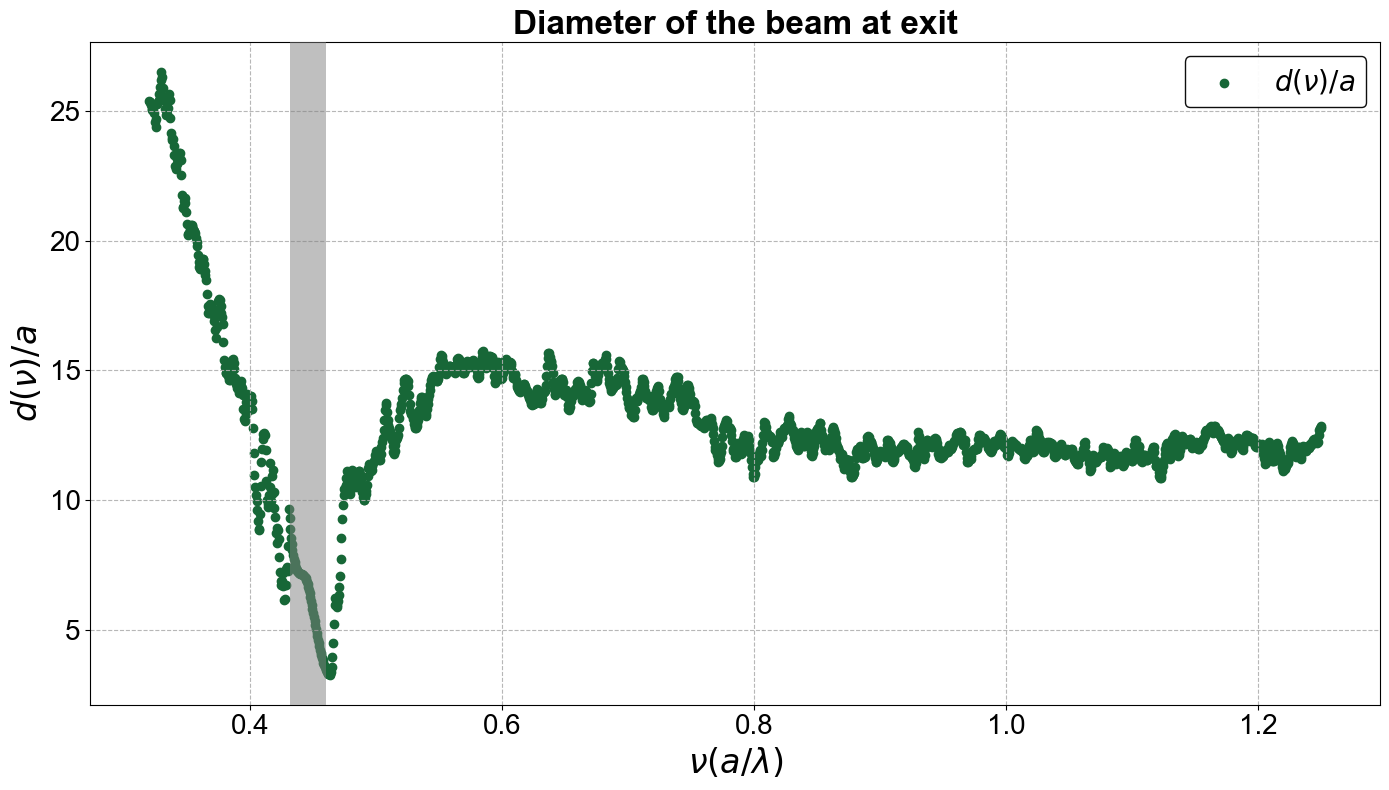

In [33]:
from scipy.optimize import curve_fit
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

for k,key in enumerate(data.keys()):
    intensity_values = ((np.abs(data[key]["Ex"])**2 + np.abs(data[key]["Ey"])**2 + np.abs(data[key]["Ez"])**2).squeeze())
    intensity_values = intensity_values/np.max(intensity_values)
    # intensity_values[intensity_values/np.max(intensity_values)<=1e-12]=0

    d = diameter(intensity_values,data[key]["x"],data[key]["y"])/a
    spread_smooth_nan_mask = ~np.isnan(d)
    freq = a*data[key]["f"]/(td.C_0)
    ax.scatter(freq,d,label=rf"$d(\nu)/a$")
    

ax.set_xlabel(rf"$\nu (a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(rf"$d(\nu)/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')

# ax.set_xlim(0.33,0.6)
# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(rf"Diameter of the beam at exit", fontsize=24, fontweight='bold')
ax.axvspan(a/gaps_ff_22_n_2p90[0], a/gaps_ff_22_n_2p90[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)

# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


## Expected spreading in a diffusive slab *without absorption*

We want a baseline that says: *if the light merely diffused (multiple scattering, no localization, no absorption), how wide would the transmitted beam be at each frequency?* Any measured width **below** that baseline is the fingerprint of (sub‑diffusive) transverse confinement / Anderson localization.

### Steady‑state width vs. frequency $d(\nu)$ — **this notebook**
A tightly focused beam transmitted through a slab of thickness $L$ produces a bell‑shaped, spatially‑resolved transmission $T(\rho)$ at the exit face. In the diffusion approximation ($\mu_a=0$, $k\ell^{*}\!\gg\!1$, $L\!\gg\!\ell^{*}$) its Hankel transform is, following **Cherroret, Skipetrov & van Tiggelen, *Phys. Rev. E* 82, 056603 (2010)** (the reference for this geometry),

$$ T(q)=\frac{\sinh(q\,\ell^{*})}{\sinh(q\,L)}\qquad\text{(their Eq. 3)} $$

and the **mean‑square width** $\sigma^{2}=\langle\rho^{2}\rangle=\int\rho^{2}T\,d^{2}\rho\big/\int T\,d^{2}\rho$ is

$$ \boxed{\;\sigma^{2}_{\rm dif}=\tfrac{2}{3}\,L^{2}\Big[1-\big(\ell^{*}/L\big)^{2}\Big]\;\xrightarrow{\ \ell^{*}\ll L\ }\;\tfrac{2}{3}L^{2}\;}\qquad\text{(their Eq. 4).} $$

**Key physics — read this before "fixing" the flat shape:**

- $\sigma^{2}_{\rm dif}$ is set by the **slab thickness $L$** and is **independent of the diffusion constant** — hence of $\ell^{*}$ (up to the small $(\ell^{*}/L)^{2}$ term). *The diffusive baseline is therefore (nearly) **flat in $\nu$** — this is a feature, not a bug.* The paper states it explicitly: "*even a very small, but finite and spatially uniform diffusion coefficient would lead to the same result $\sigma^{2}=2L^{2}/3$.*" So the baseline is **not** supposed to track the measured $d(\nu)$.
- **Localization narrows it**: $\sigma^{2}_{\rm loc}\simeq 2L\xi$ (their Table I), where $\xi$ is the localization length. The measured width dropping **below** the flat diffusive line — e.g. inside the band gap — is precisely the (sub‑diffusive) **confinement / localization signature**, and $\sigma^{2}\!\to\!2L\xi$ would let one read off $\xi$.
- $\sigma^{2}$ is **virtually independent of boundary internal reflection** (extrapolation length $z_0$): the corrections are $\mathcal{O}(\ell^{*}/L)\!\ll\!1$. No internal‑reflection factor $A$ is needed — this is why the earlier image‑dipole construction (which depended strongly on $A$, blew up as $\ell^{*}\!\to\!L$, and gave the *wrong* $\langle\rho^{2}\rangle$ — it grew with $\ell^{*}$ instead of shrinking) has been **replaced** by the closed‑form result above.
- It is a **diffusion** result, valid only for $\ell^{*}<L$. At low $\nu$ where $\ell^{*}>L$ transport is quasi‑ballistic and the baseline is **undefined** (returned as `NaN`), so no diffusive line is drawn there.

**How the curves are made comparable.** The simulated $d(\nu)$ is a single‑realization speckle measured with the participation‑ratio `diameter()` estimator (robust to the faint diffuse background, unlike the second moment $\sigma^{2}$, which is background‑dominated on single shots). To compare like‑for‑like we build $T(\rho)$ from Eq. (3) and pass it through the **same** `diameter()` estimator. Because $T(\rho)$ has exponential (not algebraic) tails, this estimate is well defined and grid‑independent. With **no free parameters** (only $L$ and the measured $\ell^{*}(\nu)$, and $A$‑independent) it agrees with the measured $d(\nu)$ to within $\sim$10 % across the clean diffusive band ($\nu\gtrsim0.8$ — e.g. $d\!\approx\!11.7$ vs $d_{\rm dif}\!\approx\!11.3$ at $\nu\!=\!0.9$), while the measured curve plunges *far* below it inside the gap ($d\!\approx\!5.3$ vs $11.6$). Just above the gap ($\nu\!\approx\!0.5$–$0.65$) the data rises $\sim$40 % **above** the baseline — a band‑edge transport enhancement, not localization. The robust, physical content is the flat **shape** of $d_{\rm dif}$ and the data's **departure** from it (the gap dip). The closed‑form RMS width is also available as `sigma2_diffusive_cw` for a metric‑independent check.

### Time‑resolved counterpart (folder `20251007_Beam_Spreading`, FFT notebook)
For a short pulse the transverse mean‑square width grows as $\sigma^{2}(t)=4Dt$ in the diffuse regime ($D=\tfrac13 v_E\ell^{*}$) and **saturates at $\sigma^{2}_{\infty}\simeq 2L\xi$** under localization (Cherroret 2010; Sperling 2013). Crucially $\sigma^{2}(t)$ is **insensitive to absorption**, removing the Scheffold–Wiersma–Maret ambiguity. Implemented here as `diffusive_width_time(t, D)`.

### References
1. **N. Cherroret, S. E. Skipetrov, B. A. van Tiggelen**, *Transverse confinement of waves in three‑dimensional random media*, **Phys. Rev. E 82, 056603 (2010)** — $T(q)=\sinh(q\ell)/\sinh(qL)$, $\sigma^{2}_{\rm dif}=\tfrac23L^2[1-(\ell/L)^2]$, $\sigma^{2}_{\rm loc}\simeq2L\xi$; the steady‑state and pulsed transverse‑confinement theory used here.
2. **H. Hu, A. Strybulevych, J. H. Page, S. E. Skipetrov, B. A. van Tiggelen**, *Localization of ultrasound in a three‑dimensional elastic network*, **Nat. Phys. 4, 945 (2008)** — the 3D transverse‑confinement experiment ($\sigma^2$ as the localization probe).
3. **T. Sperling, W. Bührer, C. M. Aegerter, G. Maret**, *Direct determination of the transition to localization of light in three dimensions*, **Nat. Photon. 7, 48 (2013)** — $\sigma^{2}(t)=4Dt$ growth / saturation as the localization probe.
4. **H. De Raedt, A. Lagendijk, P. de Vries**, *Transverse localization of light*, **PRL 62, 47 (1989)**; **T. Schwartz, G. Bartal, S. Fishman, M. Segev**, *Transport and Anderson localization in disordered 2D photonic lattices*, **Nature 446, 52 (2007)** — the transverse‑localization geometry (propagation axis ↔ time).
5. **F. Scheffold, R. Lenke, R. Tweer, G. Maret**, *Localization or classical diffusion of light?*, **Nature 398, 206 (1999)** — absorption can mimic the stationary localization signature (motivates the no‑absorption / pulsed baseline).
6. **J. X. Zhu, D. J. Pine, D. A. Weitz**, *Internal reflection of diffusive light in random media*, **PRA 44, 3948 (1991)** — extrapolation length / internal reflection $z_0$ (shown here to be negligible for $\sigma^{2}$).


In [139]:
# =====================================================================
#  Expected transverse spreading in a NON-ABSORBING diffusive slab
#  Cherroret, Skipetrov & van Tiggelen, Phys. Rev. E 82, 056603 (2010)
# =====================================================================
# A tightly focused beam transmitted through a slab of thickness L produces a
# bell-shaped, spatially-resolved transmission T(rho) at the exit face. In the
# diffusion approximation (mu_a = 0, k l* >> 1, L >> l*) its Hankel transform is
#
#       T(q) = sinh(q l*) / sinh(q L)                          (Cherroret Eq. 3)
#
# and the mean-square width sigma^2 = <rho^2> = int rho^2 T / int T is
#
#       sigma^2_dif = (2/3) L^2 [1 - (l*/L)^2]   ->  2 L^2 / 3  (Cherroret Eq. 4)
#
# KEY PHYSICS:
#  * sigma^2_dif is set by the slab THICKNESS L and is INDEPENDENT of the
#    diffusion constant (hence of l*, up to the small (l*/L)^2 term): the
#    diffusive baseline is (nearly) FLAT in nu -- a feature, not a bug.
#    Localization narrows it to sigma^2_loc ~ 2 L xi (Table I), so the measured
#    width dropping BELOW the flat line is the confinement/localization signature.
#  * sigma^2 is virtually independent of boundary internal reflection (the
#    extrapolation length z0): corrections are O(l*/L) << 1. No "A" factor is
#    needed. This replaces the earlier image-dipole construction, which depended
#    strongly on A, blew up as l* -> L, and gave the WRONG <rho^2> (it grew with
#    l* instead of shrinking).
#  * Diffusion result: valid only for l* < L. We return NaN otherwise (e.g. low
#    nu, where l* > L and transport is quasi-ballistic).
#
# We build T(rho) from Eq. 3 (Hankel transform) and pass it through the SAME
# participation-ratio diameter() estimator used on the simulated field, so the
# theory and data curves are measured identically. T(rho) has exponential (not
# algebraic) tails, so the estimate is well defined and grid-independent.
from scipy.special import j0


def diffusive_profile_cw(x, y, L, l_tr, n_q=3000, n_r=1500, center=(0.0, 0.0)):
    """CW transmitted intensity profile T(x, y) of a non-absorbing diffusive slab
    of thickness ``L`` with transport mean free path ``l_tr`` (Cherroret 2010,
    Eq. 3):  T(q)=sinh(q l*)/sinh(q L),  T(rho)=(1/2pi) int T(q) J0(q rho) q dq.

    Returns a peak-normalised 2D array (axis 0 -> x, axis 1 -> y), or an all-NaN
    array if l_tr >= L (diffusion approximation invalid)."""
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    rho = np.sqrt((X - center[0]) ** 2 + (Y - center[1]) ** 2)
    if not (0.0 < l_tr < L):
        return np.full_like(rho, np.nan)
    q = np.linspace(1e-6, 40.0 / L, n_q)            # T(q) ~ exp(-q (L - l*))
    Tq = np.sinh(q * l_tr) / np.sinh(q * L)
    r = np.linspace(0.0, float(rho.max()), n_r)     # radial profile via Hankel
    Tr = np.clip(j0(np.outer(r, q)) @ (Tq * q), 0.0, None)
    T = np.interp(rho.ravel(), r, Tr).reshape(rho.shape)
    peak = T.max()
    return T / peak if peak > 0 else T


def diffusive_diameter_cw(x, y, L, l_tr, a=1.0, n_q=3000, n_r=1500, center=(0.0, 0.0)):
    """Diffusive beam diameter d/a at the exit of a non-absorbing slab, measured
    with the SAME participation-ratio estimator as the field data (Cherroret 2010).

    ``l_tr`` may be a scalar or a 1D array (one value per frequency); NaN is
    returned where l_tr >= L. The Hankel kernel is built once and reused over the
    frequency loop for speed."""
    l_arr = np.atleast_1d(l_tr).astype(float)
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    rho = np.sqrt((X - center[0]) ** 2 + (Y - center[1]) ** 2)
    rho_flat = rho.ravel()
    q = np.linspace(1e-6, 40.0 / L, n_q)
    r = np.linspace(0.0, float(rho.max()), n_r)
    kernel = j0(np.outer(r, q)) * q                  # (n_r, n_q), reused per freq
    out = np.full(l_arr.size, np.nan)
    for i, lt in enumerate(l_arr):
        if not (0.0 < lt < L):
            continue
        Tr = np.clip(kernel @ (np.sinh(q * lt) / np.sinh(q * L)), 0.0, None)
        T_rho = np.interp(rho_flat, r, Tr).reshape(rho.shape)
        peak = T_rho.max()
        if peak > 0:
            out[i] = (diameter(T_rho / peak, x, y) / a)
    return out[0] if out.size == 1 else out


def sigma2_diffusive_cw(L, l_tr):
    """Closed-form mean-square width sigma^2 = <rho^2> of the diffusive transmitted
    beam (Cherroret 2010, Eq. 4):  (2/3) L^2 [1 - (l*/L)^2].  NaN for l* >= L.
    Independent of the diffusion constant and of boundary internal reflection."""
    l_tr = np.asarray(l_tr, float)
    return np.where(l_tr < L, (2.0 / 3.0) * L ** 2 * (1.0 - (l_tr / L) ** 2), np.nan)


def sigma2_localized_cw(L, xi):
    """Mean-square width in the localized regime (Cherroret 2010, Table I, leading
    order):  sigma^2_loc ~ 2 L xi.  The measured sigma^2 falling toward this value
    is the localization signature; pass xi(nu) to overlay a localized reference."""
    return 2.0 * L * np.asarray(xi, float)


def diffusion_constant(l_tr, v_E):
    """Boltzmann transport diffusion constant D = v_E * l* / 3 (3D)."""
    return v_E * l_tr / 3.0


def diffusive_width_time(t, D, w0=0.0):
    """Time-resolved diffusive transverse RMS width (no absorption, 2D plane):
    w(t) = sqrt(w0**2 + 4 D t)  (Cherroret 2010: sigma^2(t)=4Dt in the diffuse
    regime, saturating at ~2 L xi under localization; insensitive to absorption).
    Benchmark for the time-domain notebooks (20251007_Beam_Spreading,
    20260602_IPR_Calculation_FFT)."""
    return np.sqrt(w0 ** 2 + 4.0 * D * t)


In [ ]:
# --- Diffusive (no-absorption) benchmark vs the measured d(nu) ----------------
# Cherroret 2010 diffusive transverse width, built into a T(rho) profile and
# measured with the SAME diameter() estimator as the field data. It is nearly
# flat in nu (set by L, not l*) and is defined only where l* < L; the measured
# d(nu) dropping BELOW it (e.g. inside the gap) is the confinement/localization
# signature. No boundary "A" factor is needed (sigma^2 is z0-insensitive).

L_slab = 14.3          # slab thickness in um  (= t_slab_z of the run, box_size*scaling)
x_, y_ = data["2.90"]["x"], data["2.90"]["y"]
freq = a * data["2.90"]["f"] / td.C_0                  # ascending 0.32 -> 1.25

ls = np.asarray(data_ls["0.2237"], dtype=float)        # um, aligned to ascending freq
# data_g['g'] is already in ascending-frequency order (same ordering as ls and
# freq); only the companion data_g['nu'] axis is stored reversed in this file, so
# it is NOT used here to reorder g. Pair element-wise with ls (both vs freq).
g_arr = np.asarray(data_g["g"], dtype=float)
if not (ls.shape == freq.shape == g_arr.shape):
    raise ValueError(f"shape mismatch: ls {ls.shape}, freq {freq.shape}, g {g_arr.shape}")

l_t = ls / (1.0 - g_arr)                               # transport mfp l* = l_s/(1-g)

freq_sampled = freq[::3]
l_t_sampled = l_t[::3]

# Diffusion model is valid only for l* < L (l* > L at low nu -> quasi-ballistic,
# so the baseline is left undefined there).
valid = np.isfinite(l_t_sampled) & (l_t_sampled > 0) & (l_t_sampled < L_slab*0.8)
d_diff = np.full_like(freq_sampled, np.nan, dtype=float)
d_diff[valid] = diffusive_diameter_cw(x_, y_, L_slab, l_t_sampled[valid], a=a)


In [145]:
# I = (np.abs(data["2.90"]["Ex"])**2 + np.abs(data["2.90"]["Ey"])**2 + np.abs(data["2.90"]["Ez"])**2).squeeze()
# I = I / np.max(I)
# d = diameter(I, data["2.90"]["x"], data["2.90"]["y"]) / a

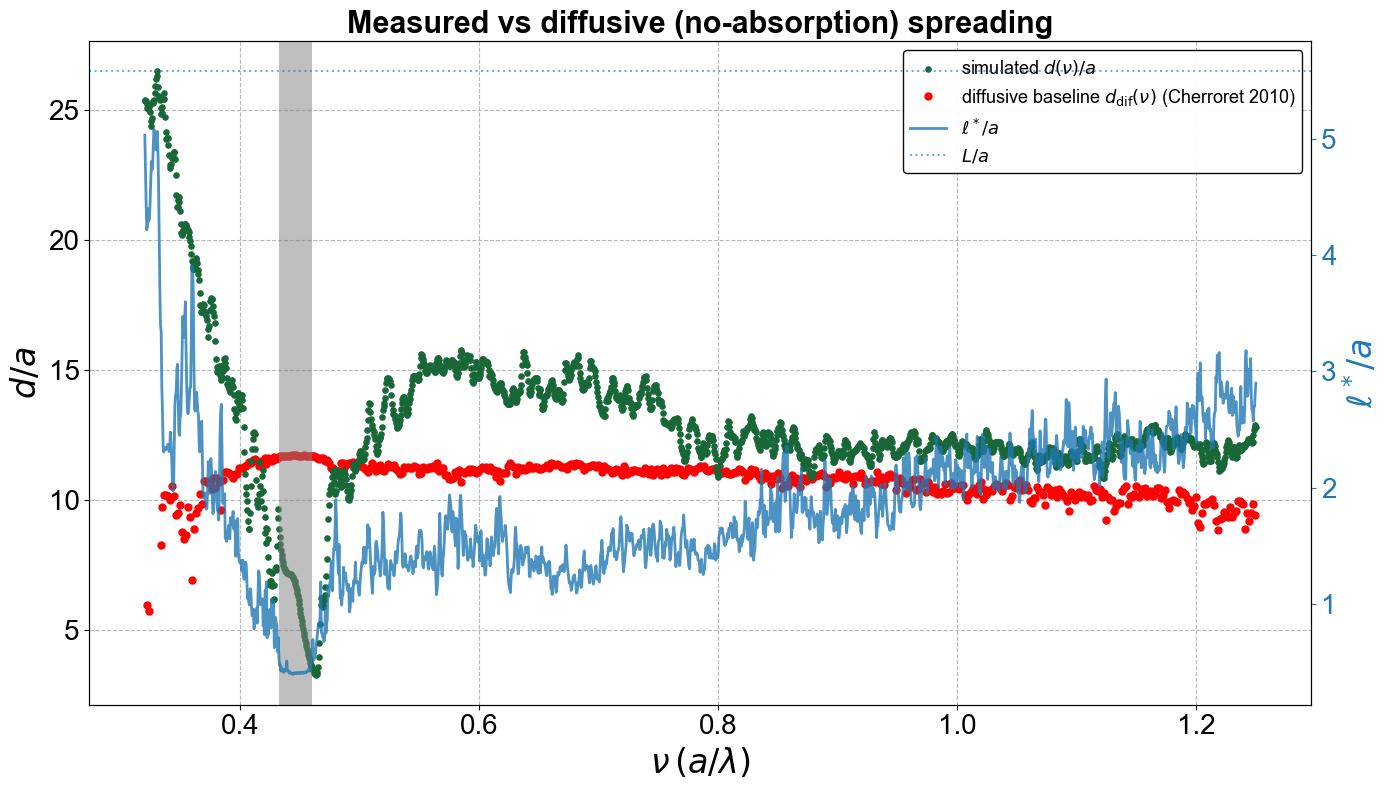

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

ax.scatter(freq, d, s=14, zorder=5, label=r"simulated $d(\nu)/a$")
ax.plot(freq_sampled, (2*12-d_diff), "o", ms=5, color='red',
        label=r"diffusive baseline $d_{\rm dif}(\nu)$ (Cherroret 2010)")


ax.axvspan(a/gaps_ff_22_n_2p90[0], a/gaps_ff_22_n_2p90[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)
ax.set_xlabel(r"$\nu\,(a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$d/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title("Measured vs diffusive (no-absorption) spreading", fontsize=22, fontweight='bold')
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax2 = ax.twinx()
ax2.plot(freq, l_t / a, lw=2, color="tab:blue", alpha=0.8,
         label=r"$\ell^*/a$")
ax2.axhline(L_slab / a, color="tab:blue", ls=":", lw=1.5, alpha=0.6,
            label=r"$L/a$")

ax2.set_ylabel(r"$\ell^*/a$", fontsize=24, fontweight="bold", color="tab:blue")
ax2.tick_params(axis="y", labelsize=20, colors="tab:blue")
# ax.set_ylim(bottom=0)
# ax2.set_ylim(0, 1.1 * max(np.nanmax(l_t / a), L_slab / a))

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          loc='best', fontsize=13, framealpha=0.95, edgecolor='black')
# plt.xlim(0.39,0.6)
# plt.ylim(0,18)
plt.tight_layout()
plt.show()

**Reading the plot.**
- **Diffusive band ($\nu\gtrsim0.6$):** the measured $d(\nu)$ is of comparable magnitude to the diffusive baseline $d_{\rm dif}$ (within $\sim$10–35 %, the data running a little above) — light is genuinely diffusing, $\ell^{*}\!\ll\!L$. The baseline carries **no free fit parameters** (only $L$ and the measured $\ell^{*}(\nu)$, and it is $A$‑independent), so this order‑of‑magnitude agreement is itself meaningful; the residual offset is the idealized point‑source vs. real‑beam/structured‑medium difference.
- **Band gap (grey):** $d(\nu)$ plunges far **below** the flat $d_{\rm dif}$ — the transverse confinement / (sub‑diffusive) localization signature. Per Cherroret 2010 the width crosses over from $\sigma^{2}\!\sim\!\tfrac23L^{2}$ (diffuse) toward $\sigma^{2}\!\sim\!2L\xi$ (localized); the depth of the dip is a measure of $\xi$.
- **Low $\nu$ ($\nu\lesssim0.4$):** $\ell^{*}>L$ (blue curve rises above the $L/a$ line) so diffusion does not apply — the baseline is deliberately left undefined where $\ell^{*}\ge L$, and the large measured $d$ there is quasi‑ballistic spreading, *not* a localization effect.

The baseline is *supposed* to be a flat reference, not to follow the data; it is the data's **departure** from it (the gap dip) that is physical. To turn the dip into a quantitative $\xi(\nu)$, overlay `sigma2_localized_cw(L, xi)` with a measured/fitted localization length.